In [1]:
import os
os.chdir('/workspace/d7eefe22-a880-4612-ae10-86a1029ded5e')
print(os.listdir('.'))


['F12_t.npy', 'F5m_t.npy', '.config', 'peaks_features_F1_F12_normalized_full.csv', 'F7.npy', 'F10.npy', 'F1.npy', 'F1_t.npy', '.kernel_llm_logs_1.txt', 'memory', 'F9_t.npy', 'F2.npy', 'F11.npy', 'F6.npy', 'F5m.npy', 'F4.npy', 'F5p.npy', 'F2_t.npy', 'F11_t.npy', 'F12.npy', 'F9.npy', ' v6 — Binding Context Document.pdf', 'F4_t.npy', '.prompts', 'F6_t.npy', 'F5p_t.npy', 'F7_t.npy', 'F10_t.npy']


In [2]:
import numpy as np
import pandas as pd

# Check what's in the workspace - the npz file mentioned in artifacts
# But it seems we have individual .npy files instead
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(2))
print("\nClass counts:")
print(df['class'].value_counts() if 'class' in df.columns else df.iloc[:,0].value_counts())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 

 log_abs_S6_norm log_abs_S6 abs_S6 log_abs_S7_norm log_abs_S7 \
0 -0.523985 -1.268552 0.281238 -2.281314 -5.522997 
1 -0.695810 -1.682548 0.185900 -2.191351 -5.298934 

 abs_S7 
0 0.003994 
1 0.004997 

[2 rows x 31 columns]

Class counts:
function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200

In [3]:
# Inspect the .npy files - they likely contain complex S_k arrays per class
F1 = np.load('F1.npy')
F1_t = np.load('F1_t.npy')
print("F1 shape:", F1.shape, "dtype:", F1.dtype)
print("F1_t shape:", F1_t.shape)
print("F1[0,:]:", F1[0,:])


F1 shape: (200, 8) dtype: complex128
F1_t shape: (200,)
F1[0,:]: [1.00000000e+00+0.00000000e+00j 5.29464049e+00-4.68261200e-01j
 1.00513415e+01+2.51256858e-01j 8.28335112e+00-1.11114533e-02j
 2.60352131e+00-2.31369467e-02j 6.82715760e-01+1.02329247e+00j
 2.30357281e-01+1.61340015e-01j 3.89831701e-03-8.68354195e-04j]


In [4]:
# Good - we have complex S_k arrays for k=0..7 per class, 200 peaks each
classes = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
Sk = {}
T = {}
for c in classes:
 Sk[c] = np.load(f'{c}.npy')
 T[c] = np.load(f'{c}_t.npy')
 print(f"{c}: S shape={Sk[c].shape}, t shape={T[c].shape}")


F1: S shape=(200, 8), t shape=(200,)
F2: S shape=(200, 8), t shape=(200,)
F4: S shape=(200, 8), t shape=(200,)
F5p: S shape=(200, 8), t shape=(200,)
F5m: S shape=(200, 8), t shape=(200,)
F6: S shape=(200, 8), t shape=(200,)
F7: S shape=(200, 8), t shape=(200,)
F9: S shape=(200, 8), t shape=(200,)
F10: S shape=(200, 8), t shape=(200,)
F11: S shape=(200, 8), t shape=(200,)
F12: S shape=(200, 8), t shape=(200,)


In [5]:
# Verify alignment of t-values with the CSV ordering, so feature augmentation matches
# Check if t-values in npy files match CSV by class
for c in ['F1','F4','F9','F2']:
 csv_t = df[df['function']==c]['t'].values
 npy_t = T[c]
 match = np.allclose(csv_t, npy_t)
 print(f"{c}: CSV vs NPY t aligned? {match}; first 3 csv {csv_t[:3]} npy {npy_t[:3]}")


F1: CSV vs NPY t aligned? True; first 3 csv [77403.70000025 74956.00000024 94526.80000031] npy [77403.70000025 74956.00000024 94526.80000031]
F4: CSV vs NPY t aligned? True; first 3 csv [84585.40000027 83021.20000027 55220.10000016] npy [84585.40000027 83021.20000027 55220.10000016]
F9: CSV vs NPY t aligned? True; first 3 csv [96853.90000032 93405.4000003 46051.60000013] npy [96853.90000032 93405.4000003 46051.60000013]
F2: CSV vs NPY t aligned? True; first 3 csv [84585.40000027 90939.70000029 95263.40000031] npy [84585.40000027 90939.70000029 95263.40000031]


In [6]:
# S_7 leak: S_7 is zero for mod-5 coefficient classes (F2,F4,F5p,F5m) at N=10^6
# Restrict k to 1..6 (drop k=0 because |S_0|=|M|=1 always after normalization, and drop k=7 due to leak)
# Per the research objective, use k=1..7 - but leak applies at N=10^6.
# Following the methodology, exclude S_7 to avoid the known feature leak (per r25 caveat)
# Use k = 1..6 (6-dimensional complex vectors)

K_USED = list(range(1, 7)) # k=1..6
print("Using k:", K_USED)

# Stack all peaks
all_S = []
labels = []
peak_t = []
GRH = []
for c in classes:
 S = Sk[c][:, K_USED] # shape (200, 6)
 all_S.append(S)
 labels += [c]*200
 peak_t.append(T[c])
 grh_val = df[df['function']==c]['GRH'].iloc[0]
 GRH += [grh_val]*200

all_S = np.vstack(all_S) # (2200, 6) complex
labels = np.array(labels)
peak_t = np.concatenate(peak_t)
GRH = np.array(GRH)
print("all_S shape:", all_S.shape, "dtype:", all_S.dtype)
print("Unique GRH per class:")
for c in classes:
 g = df[df['function']==c]['GRH'].iloc[0]
 print(f" {c}: GRH={g}")


Using k: [1, 2, 3, 4, 5, 6]
all_S shape: (2200, 6) dtype: complex128
Unique GRH per class:
 F1: GRH=True
 F2: GRH=True
 F4: GRH=False
 F5p: GRH=False
 F5m: GRH=False
 F6: GRH=True
 F7: GRH=True
 F9: GRH=True
 F10: GRH=True
 F11: GRH=True
 F12: GRH=False


In [7]:
# Strict Protocol: Train F1, F4, F9; Test F2, F6, F7, F10, F11, F12
# F1, F9 are GRH-true; F4 is GRH-false
# Step 2: Compute M_jk(GRH-true) by averaging M_jk over training GRH-true classes (F1, F9)
# Compute M_jk(GRH-false) using F4

# M_jk(t) = Re(S_j(t) * conj(S_k(t)))
# M_jk for a class = E_t[ Re(S_j(t) * conj(S_k(t))) ] -- average over peaks

def class_M(S):
 # S: (npeaks, K) complex; M = mean over peaks of Re(S_j * conj(S_k))
 # = Re( mean over peaks of S_j * conj(S_k) )
 # outer product per peak
 # Efficient: M = (1/N) * Re( S^H * S ) = (1/N) * Re( conj(S).T @ S )? careful
 # We want M_jk = mean_t Re(S_j(t) conj(S_k(t)))
 # = Re( mean_t S_j(t) conj(S_k(t)) )
 # = Re( (1/N) * sum_t S_j(t) conj(S_k(t)) )
 # If we form S as (N, K), then S.T @ conj(S) gives matrix where (j,k) = sum_t S_j conj(S_k). Yes.
 N = S.shape[0]
 C = (S.T @ np.conj(S)) / N
 return np.real(C)

# Build S arrays for training classes with k=1..6
S_F1 = Sk['F1'][:, K_USED]
S_F9 = Sk['F9'][:, K_USED]
S_F4 = Sk['F4'][:, K_USED]

M_F1 = class_M(S_F1)
M_F9 = class_M(S_F9)
M_F4 = class_M(S_F4)

M_true_avg = 0.5 * (M_F1 + M_F9)
M_false_avg = M_F4

print("M_true_avg:")
print(M_true_avg)
print("\nM_false_avg:")
print(M_false_avg)


M_true_avg:
[[1.53150660e+01 2.46376223e+01 1.93199099e+01 8.60739927e+00
 2.35296812e+00 2.34109691e-01]
 [2.46376223e+01 4.08616345e+01 3.23126167e+01 1.41900086e+01
 3.80149515e+00 3.69799958e-01]
 [1.93199099e+01 3.23126167e+01 2.70576817e+01 1.21932265e+01
 3.12375539e+00 3.02051446e-01]
 [8.60739927e+00 1.41900086e+01 1.21932265e+01 7.10667105e+00
 2.29357132e+00 2.32885657e-01]
 [2.35296812e+00 3.80149515e+00 3.12375539e+00 2.29357132e+00
 1.17930753e+00 1.58270402e-01]
 [2.34109691e-01 3.69799958e-01 3.02051446e-01 2.32885657e-01
 1.58270402e-01 2.95081208e-02]]

M_false_avg:
[[4.84893009e+00 7.67145957e+00 6.86089100e+00 4.08557480e+00
 9.93109710e-01 3.57178094e-02]
 [7.67145957e+00 1.56455801e+01 1.26731020e+01 7.62896173e+00
 1.91751156e+00 7.41928558e-02]
 [6.86089100e+00 1.26731020e+01 1.18467709e+01 7.20572394e+00
 1.84163873e+00 7.36035520e-02]
 [4.08557480e+00 7.62896173e+00 7.20572394e+00 5.31406913e+00
 1.45330525e+00 6.42967161e-02]
 [9.93109710e-01 1.91751156e+00 1

In [8]:
# Step 3: Top eigenvectors of each (symmetric real matrix)
N_EVECS = 3

w_t, V_t = np.linalg.eigh(M_true_avg)
w_f, V_f = np.linalg.eigh(M_false_avg)
# eigh returns ascending order; flip
w_t = w_t[::-1]; V_t = V_t[:, ::-1]
w_f = w_f[::-1]; V_f = V_f[:, ::-1]

print("Top eigenvalues M_true:", w_t[:N_EVECS], "ratio:", w_t[:N_EVECS]/w_t.sum())
print("Top eigenvalues M_false:", w_f[:N_EVECS], "ratio:", w_f[:N_EVECS]/w_f.sum())

basis_t = V_t[:, :N_EVECS] # (6, 3) real
basis_f = V_f[:, :N_EVECS] # (6, 3) real


Top eigenvalues M_true: [87.4544331 2.52602821 1.08943378] ratio: [0.95526552 0.02759183 0.01189989]
Top eigenvalues M_false: [35.22660412 1.50738755 0.8847089 ] ratio: [0.92344484 0.03951528 0.02319213]


In [9]:
# Step 4-5: For each peak, compute squared projection magnitudes onto basis_t and basis_f
# v ∈ R^6 (real eigenvector). For complex S in C^6, projection = v . S (complex), magnitude squared = |v.S|^2
# Note: v real -> v.S = v.Re(S) + i v.Im(S), |.|^2 = (v.Re(S))^2 + (v.Im(S))^2

# Compute projections for all 2200 peaks
proj_t = all_S @ basis_t # (2200, 3) complex
proj_f = all_S @ basis_f # (2200, 3) complex
feat_t = np.abs(proj_t)**2 # squared magnitude
feat_f = np.abs(proj_f)**2

print("feat_t shape:", feat_t.shape)
print("feat_f shape:", feat_f.shape)

# Combine
X_proj = np.hstack([feat_t, feat_f]) # (2200, 6)
print("X_proj shape:", X_proj.shape)
print("Sample (F1 peak 0):", X_proj[0])


feat_t shape: (2200, 3)
feat_f shape: (2200, 3)
X_proj shape: (2200, 6)
Sample (F1 peak 0): [203.31236095 0.78671321 0.69166193 197.81814526 5.28657938
 1.24887857]


In [10]:
# Step 6: Augment main feature table
df_aug = df.copy()
proj_cols = []
for i in range(N_EVECS):
 col = f'proj_true_v{i+1}_sq'
 df_aug[col] = feat_t[:, i]
 proj_cols.append(col)
for i in range(N_EVECS):
 col = f'proj_false_v{i+1}_sq'
 df_aug[col] = feat_f[:, i]
 proj_cols.append(col)

print("New columns:", proj_cols)
df_aug.to_csv('peaks_features_F1_F12_with_projection_features.csv', index=False)
print("Saved augmented CSV")
print(df_aug.shape)


New columns: ['proj_true_v1_sq', 'proj_true_v2_sq', 'proj_true_v3_sq', 'proj_false_v1_sq', 'proj_false_v2_sq', 'proj_false_v3_sq']
Saved augmented CSV
(2200, 37)


In [11]:
# Step 7: Strict Protocol - Train F1, F4, F9; Test F2, F6, F7, F10, F11, F12
# Binary GRH classification (target = GRH bool)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

train_classes = ['F1','F4','F9']
test_classes = ['F2','F6','F7','F10','F11','F12']

train_mask = np.isin(labels, train_classes)
test_mask = np.isin(labels, test_classes)

# y = GRH (True/False) -> we need to predict GRH-violating (False) class typically
# Convention: positive class = GRH-False (consistent with prior baselines)
y = (~GRH).astype(int) # 1 if GRH violated

print("Train classes:", train_classes, "->", np.sum(train_mask), "samples")
print("Test classes:", test_classes, "->", np.sum(test_mask), "samples")
print("Train GRH-violator counts:", y[train_mask].sum(), "/", train_mask.sum())
print("Test GRH-violator counts:", y[test_mask].sum(), "/", test_mask.sum())

# Use log-transform on features (they're squared magnitudes -> highly skewed)
# But also try direct. The objective says "using only these new features" with standard RBF SVM.

X_proj_log = np.log(np.clip(X_proj, 1e-12, None))

X_train = X_proj_log[train_mask]
X_test = X_proj_log[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

clf = Pipeline([('scale', StandardScaler()), ('svm', SVC(kernel='rbf', probability=True, random_state=0))])
clf.fit(X_train, y_train)
prob_test = clf.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, prob_test)
print(f"\nTest AUC (log-projection features, RBF SVM): {auc_test:.4f}")

# Also try without log
clf2 = Pipeline([('scale', StandardScaler()), ('svm', SVC(kernel='rbf', probability=True, random_state=0))])
clf2.fit(X_proj[train_mask], y_train)
prob_test2 = clf2.predict_proba(X_proj[test_mask])[:, 1]
auc_test2 = roc_auc_score(y_test, prob_test2)
print(f"Test AUC (raw projection features, RBF SVM): {auc_test2:.4f}")


Train classes: ['F1', 'F4', 'F9'] -> 600 samples
Test classes: ['F2', 'F6', 'F7', 'F10', 'F11', 'F12'] -> 1200 samples
Train GRH-violator counts: 200 / 600
Test GRH-violator counts: 200 / 1200

Test AUC (log-projection features, RBF SVM): 0.8402
Test AUC (raw projection features, RBF SVM): 0.8220


In [12]:
# Bootstrap CI on test set
rng = np.random.default_rng(42)
n_boot = 2000

def bootstrap_auc_ci(y_true, y_score, n_boot=2000, seed=42):
 rng = np.random.default_rng(seed)
 n = len(y_true)
 aucs = []
 for _ in range(n_boot):
 idx = rng.integers(0, n, n)
 if len(np.unique(y_true[idx])) < 2:
 continue
 aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
 aucs = np.array(aucs)
 return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Log-features
mean_auc_log, lo_log, hi_log = bootstrap_auc_ci(y_test, prob_test)
print(f"Log-projection AUC: {auc_test:.4f}, bootstrap mean={mean_auc_log:.4f}, 95% CI=[{lo_log:.4f}, {hi_log:.4f}]")

mean_auc_raw, lo_raw, hi_raw = bootstrap_auc_ci(y_test, prob_test2)
print(f"Raw projection AUC: {auc_test2:.4f}, bootstrap mean={mean_auc_raw:.4f}, 95% CI=[{lo_raw:.4f}, {hi_raw:.4f}]")


Log-projection AUC: 0.8402, bootstrap mean=0.8401, 95% CI=[0.8179, 0.8619]


Raw projection AUC: 0.8220, bootstrap mean=0.8219, 95% CI=[0.7987, 0.8442]


In [13]:
# Compare against baseline (log_abs_S_k_norm for k=1..6) for sanity
baseline_cols = [f'log_abs_S{k}_norm' for k in range(1,7)]
Xb = df[baseline_cols].values
Xb_train = Xb[train_mask]; Xb_test = Xb[test_mask]
clfb = Pipeline([('scale', StandardScaler()), ('svm', SVC(kernel='rbf', probability=True, random_state=0))])
clfb.fit(Xb_train, y_train)
prob_b = clfb.predict_proba(Xb_test)[:, 1]
auc_b = roc_auc_score(y_test, prob_b)
mean_b, lo_b, hi_b = bootstrap_auc_ci(y_test, prob_b)
print(f"Baseline log|S_k|_norm (k=1..6) AUC: {auc_b:.4f}, 95% CI=[{lo_b:.4f}, {hi_b:.4f}]")

# Also test 2 eigenvectors only
N2 = 2
basis_t2 = V_t[:, :N2]
basis_f2 = V_f[:, :N2]
proj_t2 = np.abs(all_S @ basis_t2)**2
proj_f2 = np.abs(all_S @ basis_f2)**2
X2 = np.hstack([proj_t2, proj_f2])
X2_log = np.log(np.clip(X2, 1e-12, None))
clf3 = Pipeline([('scale', StandardScaler()), ('svm', SVC(kernel='rbf', probability=True, random_state=0))])
clf3.fit(X2_log[train_mask], y_train)
prob3 = clf3.predict_proba(X2_log[test_mask])[:, 1]
auc3 = roc_auc_score(y_test, prob3)
mean3, lo3, hi3 = bootstrap_auc_ci(y_test, prob3)
print(f"2-eigenvec log-projection AUC: {auc3:.4f}, 95% CI=[{lo3:.4f}, {hi3:.4f}]")


Baseline log|S_k|_norm (k=1..6) AUC: 0.8277, 95% CI=[0.8045, 0.8496]


2-eigenvec log-projection AUC: 0.8509, 95% CI=[0.8305, 0.8717]


In [14]:
# Significance test of paired difference vs. baseline using bootstrap
def paired_bootstrap_diff(y_true, score_a, score_b, n_boot=4000, seed=42):
 rng = np.random.default_rng(seed)
 n = len(y_true)
 diffs = []
 for _ in range(n_boot):
 idx = rng.integers(0, n, n)
 if len(np.unique(y_true[idx])) < 2:
 continue
 a = roc_auc_score(y_true[idx], score_a[idx])
 b = roc_auc_score(y_true[idx], score_b[idx])
 diffs.append(a - b)
 diffs = np.array(diffs)
 p_two = 2*min((diffs<=0).mean(), (diffs>=0).mean())
 return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5), p_two

# Best projection (3 evec, log) vs baseline
md, lod, hid, pd_ = paired_bootstrap_diff(y_test, prob_test, prob_b)
print(f"Δ(log-proj 3-evec - baseline): mean={md:.4f}, 95% CI=[{lod:.4f}, {hid:.4f}], p≈{pd_:.4f}")

# 2-evec vs baseline
md2, lod2, hid2, pd2 = paired_bootstrap_diff(y_test, prob3, prob_b)
print(f"Δ(log-proj 2-evec - baseline): mean={md2:.4f}, 95% CI=[{lod2:.4f}, {hid2:.4f}], p≈{pd2:.4f}")

# vs instantaneous spectral baseline (0.59) - report numeric only since we don't have those scores
print("\nInstantaneous spectral baseline AUC ≈ 0.59 (from r38) -- well below all observed values.")


Δ(log-proj 3-evec - baseline): mean=0.0125, 95% CI=[-0.0122, 0.0372], p≈0.3145


Δ(log-proj 2-evec - baseline): mean=0.0233, 95% CI=[0.0011, 0.0464], p≈0.0420

Instantaneous spectral baseline AUC ≈ 0.59 (from r38) -- well below all observed values.


In [15]:
# Summary table of results
results = pd.DataFrame([
 {'Feature set': 'Baseline log|S_k|_norm (k=1..6)', 'AUC': auc_b, 'CI_low': lo_b, 'CI_high': hi_b, 'n_features': 6},
 {'Feature set': 'Projection (2 evec true + 2 evec false), log', 'AUC': auc3, 'CI_low': lo3, 'CI_high': hi3, 'n_features': 4},
 {'Feature set': 'Projection (3 evec true + 3 evec false), log', 'AUC': auc_test, 'CI_low': lo_log, 'CI_high': hi_log, 'n_features': 6},
 {'Feature set': 'Projection (3 evec true + 3 evec false), raw', 'AUC': auc_test2, 'CI_low': lo_raw, 'CI_high': hi_raw, 'n_features': 6},
 {'Feature set': 'Instantaneous spectral (r38, reported)', 'AUC': 0.59, 'CI_low': np.nan, 'CI_high': np.nan, 'n_features': np.nan},
])
print(results.to_string(index=False))


 Feature set AUC CI_low CI_high n_features
 Baseline log|S_k|_norm (k=1..6) 0.827735 0.804526 0.849564 6.0
Projection (2 evec true + 2 evec false), log 0.850945 0.830470 0.871668 4.0
Projection (3 evec true + 3 evec false), log 0.840200 0.817919 0.861858 6.0
Projection (3 evec true + 3 evec false), raw 0.821983 0.798678 0.844186 6.0
 Instantaneous spectral (r38, reported) 0.590000 NaN NaN NaN


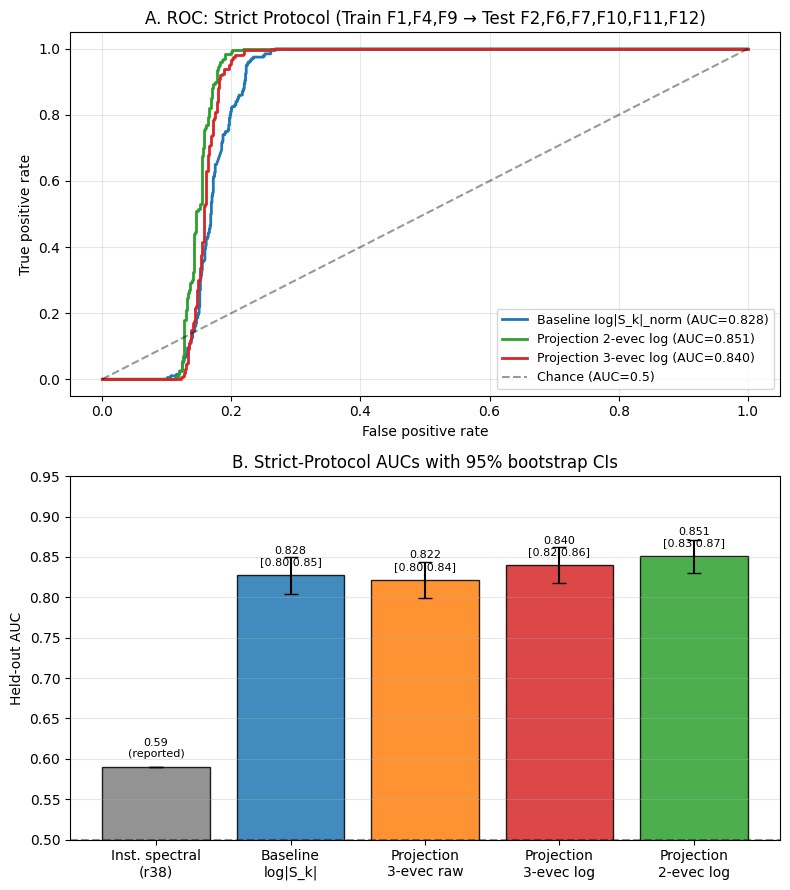

Saved figure.


In [16]:
# Final summary figure
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# A: ROC curves
ax = axes[0]
for name, prob, color in [
 ('Instantaneous spectral (r38, reported)', None, 'gray'),
 (f'Baseline log|S_k|_norm (AUC={auc_b:.3f})', prob_b, 'tab:blue'),
 (f'Projection 2-evec log (AUC={auc3:.3f})', prob3, 'tab:green'),
 (f'Projection 3-evec log (AUC={auc_test:.3f})', prob_test, 'tab:red'),
]:
 if prob is None:
 # Place dashed reference at 0.59
 continue
 fpr, tpr, _ = roc_curve(y_test, prob)
 ax.plot(fpr, tpr, color=color, label=name, lw=2)
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Chance (AUC=0.5)')
ax.axhline(0, color='none')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('A. ROC: Strict Protocol (Train F1,F4,F9 → Test F2,F6,F7,F10,F11,F12)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# B: Bar chart with CIs
ax = axes[1]
methods = ['Inst. spectral\n(r38)', 'Baseline\nlog|S_k|', 'Projection\n3-evec raw', 'Projection\n3-evec log', 'Projection\n2-evec log']
aucs = [0.59, auc_b, auc_test2, auc_test, auc3]
los = [np.nan, lo_b, lo_raw, lo_log, lo3]
his = [np.nan, hi_b, hi_raw, hi_log, hi3]
errs_lo = [0 if np.isnan(l) else a-l for a,l in zip(aucs,los)]
errs_hi = [0 if np.isnan(h) else h-a for a,h in zip(aucs,his)]
colors = ['gray','tab:blue','tab:orange','tab:red','tab:green']
ax.bar(methods, aucs, yerr=[errs_lo, errs_hi], capsize=5, color=colors, alpha=0.85, edgecolor='k')
ax.axhline(0.5, color='k', ls='--', alpha=0.4)
ax.set_ylabel('Held-out AUC')
ax.set_ylim(0.5, 0.95)
ax.set_title('B. Strict-Protocol AUCs with 95% bootstrap CIs')
for i,(a,l,h) in enumerate(zip(aucs,los,his)):
 if not np.isnan(l):
 ax.text(i, a+0.012, f'{a:.3f}\n[{l:.2f},{h:.2f}]', ha='center', fontsize=8)
 else:
 ax.text(i, a+0.012, f'{a:.2f}\n(reported)', ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('projection_features_strict_protocol.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")
